# Laboratorio 09 - Estrategias de Particion de Datos
 **Integrantes:**

 🩷 Susana Paola García García

 💙 Harriett Alexandra Guzmán López

In [50]:
# PASO 3 - DEFINIR LAS DOS PREGUNTAS DE NEGOCIO

# Pregunta 1:
# ¿Este pedido recibirá calificación baja?

cal = df.dropna(subset=['calificacion']).copy()

# Una calificación de 1 o 2 se considera baja
cal['baja'] = (cal['calificacion'] <= 2).astype(int)

print("\n=== PORCENTAJE DE PEDIDOS CON CALIFICACIÓN BAJA ===")
print(cal['baja'].mean())

# Pregunta 2:
# ¿Cuántos minutos tardará el pedido?

# Eliminamos tiempos imposibles o extremos
reg = df[
    (df['tiempo_entrega_min'] > 0) &
    (df['tiempo_entrega_min'] < 200)
].copy()

print("\n=== REGISTROS VÁLIDOS PARA REGRESIÓN ===")
print(len(reg))

print("\n=== COLUMNAS DEL DATASET ===")
print(df.columns.tolist())


=== PORCENTAJE DE PEDIDOS CON CALIFICACIÓN BAJA ===
0.09137055837563451

=== REGISTROS VÁLIDOS PARA REGRESIÓN ===
622

=== COLUMNAS DEL DATASET ===
['pedido_id', 'fecha', 'departamento', 'municipio', 'zona', 'restaurante', 'categoria_restaurante', 'metodo_pago', 'total_pedido_gtq', 'tiempo_entrega_min', 'distancia_km', 'calificacion']


In [51]:
# MODELO M1 - REGRESIÓN LOGÍSTICA

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, recall_score


NUM = ['distancia_km', 'total_pedido_gtq']

CAT = [
    'zona',
    'categoria_restaurante',
    'metodo_pago'
]

FEATURES = NUM + CAT


def nuevo_modelo():
    """M1. Siempre se crea nuevo; nunca se reutiliza uno ya entrenado."""

    prep = ColumnTransformer([
        (
            'num',
            Pipeline([
                ('imp', SimpleImputer(strategy='median')),
                ('esc', StandardScaler())
            ]),
            NUM
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            CAT
        ),
    ])

    return Pipeline([
        ('prep', prep),
        (
            'clf',
            LogisticRegression(
                max_iter=1000,
                class_weight='balanced'
            )
        ),
    ])


def entrenar_y_medir(train, test, target='baja'):
    """Entrena M1 con 'train', mide en 'test' y devuelve F1 y recall."""

    m = nuevo_modelo()

    m.fit(
        train[FEATURES],
        train[target]
    )

    pred = m.predict(test[FEATURES])

    return {
        'f1': f1_score(test[target], pred),
        'recall': recall_score(test[target], pred),
        'n_test': len(test),
        'positivos_test': int(test[target].sum())
    }

In [52]:
# MODELO M0 - BASELINE

def medir_baseline(train, test, target='baja'):
    """M0: modelo "tonto". Predice siempre la clase más común."""

    d = DummyClassifier(strategy='most_frequent')

    d.fit(
        train[FEATURES],
        train[target]
    )

    return f1_score(
        test[target],
        d.predict(test[FEATURES])
    )

## Parte A — Cinco resultados con la misma base

**Predicción antes de ejecutar:**
Creemos que los valores de F1 serán parecidos, pero no exactamente iguales.
Aunque se utiliza el mismo modelo y el mismo conjunto de datos, cada semilla
cambia qué pedidos quedan en entrenamiento y cuáles quedan en prueba, por lo
que las métricas pueden variar.

In [53]:
import pandas as pd
# PARTE A - CINCO RESULTADOS CON LA MISMA BASE

from sklearn.model_selection import train_test_split

filas = []

for semilla in [0, 1, 7, 42, 2026]:

    train, test = train_test_split(
        cal,
        test_size=0.2,
        random_state=semilla
    )

    # Medir modelo M1
    r = entrenar_y_medir(train, test)

    # Guardar semilla utilizada
    r['semilla'] = semilla

    # Medir modelo M0
    r['f1_baseline'] = medir_baseline(train, test)

    filas.append(r)


# Crear tabla con todos los resultados
resultados_A = pd.DataFrame(filas)

# Calcular porcentaje de positivos
resultados_A['porcentaje_positivos'] = (
    resultados_A['positivos_test'] /
    resultados_A['n_test'] * 100
)

print("\n=== PARTE A - RESULTADOS ===")

print(
    resultados_A[
        [
            'semilla',
            'positivos_test',
            'porcentaje_positivos',
            'f1',
            'f1_baseline'
        ]
    ]
)


=== PARTE A - RESULTADOS ===
   semilla  positivos_test  porcentaje_positivos        f1  f1_baseline
0        0              15             12.605042  0.226415          0.0
1        1              12             10.084034  0.245614          0.0
2        7              11              9.243697  0.113208          0.0
3       42              14             11.764706  0.166667          0.0
4     2026               3              2.521008  0.095238          0.0


### Pregunta 1

Si queremos predecir el tiempo de entrega desde el momento en que entra el pedido, no podemos utilizar `tiempo_entrega_min` ni `calificacion` como variables de entrada.

`tiempo_entrega_min` es precisamente el valor que queremos predecir, por lo que todavía no existe cuando entra el pedido. La `calificacion` tampoco está disponible en ese momento, ya que el cliente la proporciona después de recibir el pedido.

Las demás variables pueden utilizarse siempre que estén disponibles al momento de registrar el pedido.

### Pregunta 2

**Predicción antes de ejecutar:**
Creemos que el F1 del modelo M0 será muy bajo, posiblemente 0, porque siempre predice la clase más común ("no será baja"). Debido a que solamente alrededor del 9.14 % de los pedidos tienen calificación baja, la clase mayoritaria corresponde a pedidos que no tienen calificación baja.

### Pregunta 3

El mejor F1 fue 0.2456 y el peor fue 0.0952, por lo que existe una diferencia aproximada de 0.1504. Nos parece una diferencia considerable, ya que el modelo es exactamente el mismo y lo único que cambió fue la forma aleatoria de dividir los datos.

### Pregunta 4

Ambos grupos pueden tener razón aunque obtengan F1 diferentes, porque una partición aleatoria puede colocar observaciones distintas en entrenamiento y prueba. Por esta razón, no sería conveniente reportar únicamente el resultado de una semilla. Sería más representativo utilizar varias particiones y reportar un resultado promedio junto con su variación.

### Pregunta 5

Se observa que la cantidad de casos positivos cambia considerablemente entre las semillas. Por ejemplo, la semilla 0 tuvo 15 positivos, mientras que la semilla 2026 solamente tuvo 3. Esto demuestra que una división aleatoria puede producir conjuntos de prueba con distribuciones muy diferentes, lo que también puede generar variaciones importantes en el F1.

## Parte B — Forzar la proporción

**Predicción antes de ejecutar:**
Creemos que `stratify` no necesariamente hará que el F1 promedio aumente. Lo que esperamos es que los resultados sean más estables entre las diferentes semillas, porque cada conjunto de prueba conservará aproximadamente la misma proporción de pedidos con calificación baja.

In [54]:
# PARTE B - SPLIT CON STRATIFY

filas_b = []

for semilla in [0, 1, 7, 42, 2026]:

    train, test = train_test_split(
        cal,
        test_size=0.2,
        random_state=semilla,
        stratify=cal['baja']
    )

    # Medir modelo M1
    r = entrenar_y_medir(train, test)

    # Guardar semilla
    r['semilla'] = semilla

    # Medir modelo M0
    r['f1_baseline'] = medir_baseline(train, test)

    filas_b.append(r)


resultados_B = pd.DataFrame(filas_b)

# Porcentaje de positivos dentro del test
resultados_B['porcentaje_positivos'] = (
    resultados_B['positivos_test']
    / resultados_B['n_test']
    * 100
)

print("\n=== PARTE B - RESULTADOS CON STRATIFY ===")

print(
    resultados_B[
        [
            'semilla',
            'positivos_test',
            'porcentaje_positivos',
            'f1',
            'f1_baseline'
        ]
    ]
)


=== PARTE B - RESULTADOS CON STRATIFY ===
   semilla  positivos_test  porcentaje_positivos        f1  f1_baseline
0        0              11              9.243697  0.145455          0.0
1        1              11              9.243697  0.212766          0.0
2        7              11              9.243697  0.156250          0.0
3       42              11              9.243697  0.229508          0.0
4     2026              11              9.243697  0.140351          0.0


### Pregunta 6

Al utilizar `stratify`, todas las semillas tuvieron 11 casos positivos en el conjunto de prueba, equivalentes aproximadamente al 9.24 %. En la Parte A la cantidad variaba entre 3 y 15 positivos.

El F1 todavía cambia entre semillas, pero se eliminó la gran variación en la proporción de la clase positiva. Por lo tanto, `stratify` principalmente hizo que las particiones fueran más representativas y comparables, aunque no garantiza que el F1 sea mayor.

### Predicción Parte C

Creemos que el F1 obtenido al entrenar con enero-junio y evaluar con julio-agosto puede ser menor que el obtenido mediante una división aleatoria. Esto se debe a que el comportamiento de los pedidos puede cambiar con el tiempo y el modelo tendrá que predecir observaciones futuras que no estuvieron disponibles durante su entrenamiento.


=== PORCENTAJE DE CALIFICACIONES BAJAS POR MES ===
mes
2026-01     7.142857
2026-02     9.876543
2026-03    10.126582
2026-04     7.792208
2026-05     6.666667
2026-06    12.000000
2026-07     1.315789
2026-08    17.808219
Freq: M, Name: baja, dtype: float64


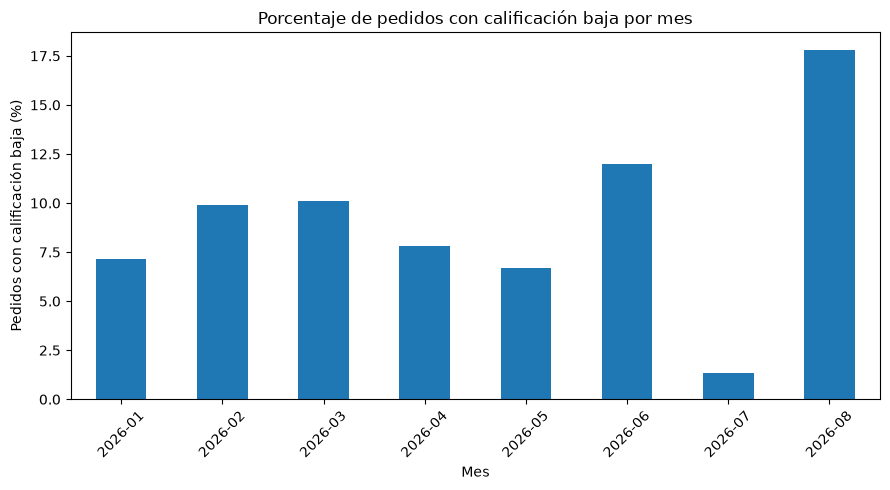

In [55]:
# PARTE C - COMPORTAMIENTO POR MES

import matplotlib.pyplot as plt

# Crear una copia para evitar modificar cal directamente
cal_mes = cal.copy()

# Obtener el mes de cada pedido
cal_mes['mes'] = cal_mes['fecha'].dt.to_period('M')

# Calcular porcentaje de calificaciones bajas por mes
bajas_por_mes = (
    cal_mes.groupby('mes')['baja'].mean() * 100
)

print("\n=== PORCENTAJE DE CALIFICACIONES BAJAS POR MES ===")
print(bajas_por_mes)


# Gráfica
bajas_por_mes.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Porcentaje de pedidos con calificación baja por mes')
plt.xlabel('Mes')
plt.ylabel('Pedidos con calificación baja (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [56]:
# PARTE C - ENTRENAR CON EL PASADO Y PROBAR CON EL FUTURO

train_t = cal[
    cal.fecha < '2026-07-01'
]

test_t = cal[
    cal.fecha >= '2026-07-01'
]

resultado_C = entrenar_y_medir(
    train_t,
    test_t
)

baseline_C = medir_baseline(
    train_t,
    test_t
)

print("\n=== PARTE C - SPLIT POR FECHA ===")

print("Pedidos en train:", len(train_t))
print("Pedidos en test:", len(test_t))

print("\nM1:")
print(resultado_C)

print("\nF1 de M0:")
print(baseline_C)


=== PARTE C - SPLIT POR FECHA ===
Pedidos en train: 442
Pedidos en test: 149

M1:
{'f1': 0.037037037037037035, 'recall': 0.07142857142857142, 'n_test': 149, 'positivos_test': 14}

F1 de M0:
0.0


### Pregunta 9

Sí, nuestra predicción se cumplió. El F1 por fecha fue aproximadamente 0.0370, considerablemente menor que los resultados obtenidos mediante las divisiones aleatorias.

Una posible explicación es que el comportamiento cambia con el tiempo. Esto se observa en el porcentaje mensual de calificaciones bajas: julio presentó aproximadamente 1.32 %, mientras que agosto aumentó hasta aproximadamente 17.81 %. El modelo fue entrenado únicamente con información de enero a junio, por lo que tuvo dificultades para generalizar ante este comportamiento futuro.

### Pregunta 10

La medición por fecha representa mejor la situación de Ruta Verde si el modelo será utilizado en septiembre. En producción, el modelo será entrenado con información del pasado para realizar predicciones sobre pedidos futuros que todavía no existen.

Por esta razón, separar los datos cronológicamente reproduce mejor la situación real que mezclar pedidos de diferentes meses aleatoriamente.

### Pregunta 11

Lo extraño del split aleatorio es que permite utilizar pedidos futuros para entrenar un modelo que después se evalúa con pedidos más antiguos. Esto no representa correctamente cómo funcionaría el sistema en producción, ya que en la vida real no podemos utilizar información del futuro para predecir el pasado.

### Predicción Parte D

Creemos que el F1 disminuirá al dejar dos restaurantes completos fuera del entrenamiento. El modelo será evaluado con restaurantes que nunca observó durante su entrenamiento, por lo que tendrá que generalizar a grupos completamente nuevos.

In [57]:
# PARTE D - PASO 1
# RESTAURANTES QUE APARECEN EN TRAIN Y TEST

train_d, test_d = train_test_split(
    cal,
    test_size=0.2,
    random_state=42
)

rest_train = set(train_d['restaurante'].unique())
rest_test = set(test_d['restaurante'].unique())

rest_comunes = rest_train.intersection(rest_test)

print("=== RESTAURANTES EN TRAIN ===")
print(rest_train)

print("\n=== RESTAURANTES EN TEST ===")
print(rest_test)

print("\n=== RESTAURANTES PRESENTES EN AMBOS ===")
print(rest_comunes)

print("\nCantidad:", len(rest_comunes))

=== RESTAURANTES EN TRAIN ===
{'Burger Xelajú', 'Pollo Real', 'Tacos El Chapín', 'Pizza Volcán', 'Sushi Ixchel', 'Pupusas Doña Lupe', 'Café Chuwa'}

=== RESTAURANTES EN TEST ===
{'Burger Xelajú', 'Pollo Real', 'Tacos El Chapín', 'Pizza Volcán', 'Sushi Ixchel', 'Pupusas Doña Lupe', 'Café Chuwa'}

=== RESTAURANTES PRESENTES EN AMBOS ===
{'Burger Xelajú', 'Pollo Real', 'Tacos El Chapín', 'Pizza Volcán', 'Sushi Ixchel', 'Pupusas Doña Lupe', 'Café Chuwa'}

Cantidad: 7


In [58]:
# PARTE D - SPLIT POR RESTAURANTE

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=2/7,
    random_state=42
)

i_tr, i_te = next(
    gss.split(
        cal,
        cal['baja'],
        groups=cal['restaurante']
    )
)

train_g = cal.iloc[i_tr]
test_g = cal.iloc[i_te]

print("=== RESTAURANTES UTILIZADOS PARA ENTRENAR ===")
print(train_g['restaurante'].unique())

print("\n=== RESTAURANTES UTILIZADOS PARA TEST ===")
print(test_g['restaurante'].unique())


resultado_D = entrenar_y_medir(
    train_g,
    test_g
)

baseline_D = medir_baseline(
    train_g,
    test_g
)

print("\n=== PARTE D - RESULTADOS ===")

print("\nM1:")
print(resultado_D)

print("\nF1 de M0:")
print(baseline_D)

=== RESTAURANTES UTILIZADOS PARA ENTRENAR ===
<StringArray>
[  'Tacos El Chapín',      'Pizza Volcán', 'Pupusas Doña Lupe',
      'Sushi Ixchel',        'Pollo Real']
Length: 5, dtype: str

=== RESTAURANTES UTILIZADOS PARA TEST ===
<StringArray>
['Café Chuwa', 'Burger Xelajú']
Length: 2, dtype: str

=== PARTE D - RESULTADOS ===

M1:
{'f1': 0.10344827586206896, 'recall': 0.21428571428571427, 'n_test': 178, 'positivos_test': 14}

F1 de M0:
0.0


### Pregunta 12

Al separar los datos por restaurante, el modelo M1 obtuvo un F1 de aproximadamente 0.1034. El desempeño fue menor que varios de los resultados obtenidos mediante las divisiones aleatorias.

Esto puede ocurrir porque Café Chuwa y Burger Xelajú quedaron completamente fuera del entrenamiento. Por lo tanto, el modelo fue evaluado con pedidos pertenecientes a restaurantes que nunca había observado durante el entrenamiento, lo cual hace más difícil la generalización.

### Pregunta 13

La medición por restaurante es la que mejor representa el escenario de un restaurante nuevo. Esta partición deja restaurantes completos fuera del entrenamiento y posteriormente utiliza sus pedidos como prueba.

Por lo tanto, simula la situación en la que Ruta Verde comienza a trabajar con un restaurante del cual el modelo nunca ha observado pedidos anteriormente.

## Parte E — Un atajo tentador

### Predicción

Creemos que la versión 1 obtendrá un F1 mayor, porque el promedio de riesgo de cada restaurante se calcula utilizando todos los pedidos, incluyendo aquellos que posteriormente formarán parte del conjunto de prueba.

Sin embargo, este resultado podría ser demasiado optimista, porque el modelo estaría utilizando indirectamente información del test que no debería conocer durante el entrenamiento.

In [59]:
# PARTE E - VERSIÓN 1
# PROMEDIO CALCULADO CON TODO EL DATASET

# Promedio de calificaciones bajas por restaurante
# IMPORTANTE: aquí se utilizan TODOS los pedidos
prom = cal.groupby('restaurante')['baja'].mean()

# Crear nueva variable
cal_v1 = cal.assign(
    riesgo_rest=cal['restaurante'].map(prom)
)

# Agregar riesgo_rest a las variables numéricas
NUM = [
    'distancia_km',
    'total_pedido_gtq',
    'riesgo_rest'
]

FEATURES = NUM + CAT


# Dividir después de haber calculado el promedio
train_v1, test_v1 = train_test_split(
    cal_v1,
    test_size=0.2,
    random_state=42,
    stratify=cal_v1['baja']
)


# Evaluar M1 y M0
resultado_E1 = entrenar_y_medir(
    train_v1,
    test_v1
)

baseline_E1 = medir_baseline(
    train_v1,
    test_v1
)


print("=== PARTE E - VERSIÓN 1 ===")

print("\nM1:")
print(resultado_E1)

print("\nF1 de M0:")
print(baseline_E1)

=== PARTE E - VERSIÓN 1 ===

M1:
{'f1': 0.22950819672131148, 'recall': 0.6363636363636364, 'n_test': 119, 'positivos_test': 11}

F1 de M0:
0.0


In [60]:
# PARTE E - VERSIÓN 2
# PRIMERO DIVIDIR Y DESPUÉS CALCULAR EL PROMEDIO

# Primero dividir los datos originales
train, test = train_test_split(
    cal,
    test_size=0.2,
    random_state=42,
    stratify=cal['baja']
)


# Calcular el promedio utilizando SOLAMENTE train
prom_tr = train.groupby(
    'restaurante'
)['baja'].mean()


# Agregar riesgo_rest al entrenamiento
train_v2 = train.assign(
    riesgo_rest=train['restaurante'].map(prom_tr)
)


# Para test utilizamos únicamente los promedios
# aprendidos a partir del train
test_v2 = test.assign(
    riesgo_rest=test['restaurante'].map(prom_tr)
)


# Evaluar M1 y M0
resultado_E2 = entrenar_y_medir(
    train_v2,
    test_v2
)

baseline_E2 = medir_baseline(
    train_v2,
    test_v2
)


print("=== PARTE E - VERSIÓN 2 ===")

print("\nM1:")
print(resultado_E2)

print("\nF1 de M0:")
print(baseline_E2)

=== PARTE E - VERSIÓN 2 ===

M1:
{'f1': 0.22950819672131148, 'recall': 0.6363636363636364, 'n_test': 119, 'positivos_test': 11}

F1 de M0:
0.0


In [61]:
# RESTAURAR VARIABLES ORIGINALES DEL MODELO

NUM = [
    'distancia_km',
    'total_pedido_gtq'
]

FEATURES = NUM + CAT

### Pregunta 14

Las dos versiones obtuvieron exactamente el mismo F1: aproximadamente 0.2295. Por lo tanto, en este experimento la versión 1 no obtuvo una ventaja observable sobre la versión 2.

Sin embargo, la versión 1 sí tenía información que la versión 2 no debía tener: para calcular `riesgo_rest` utilizó todos los pedidos, incluyendo los que posteriormente quedaron en el conjunto de prueba. La versión 2 calculó ese promedio únicamente con los datos de entrenamiento.

Aunque en este caso la fuga de información no aumentó el F1, la metodología de la versión 1 sigue siendo incorrecta porque utiliza información del test antes de evaluar el modelo.

### Pregunta 15

Si se reportara la versión 1 como resultado oficial, existiría el riesgo de presentar una evaluación demasiado optimista. En producción no será posible calcular las variables utilizando información de pedidos futuros.

En nuestro experimento ambas versiones obtuvieron el mismo F1, pero esto no elimina el problema metodológico: el conjunto de prueba debe permanecer completamente separado durante la preparación y entrenamiento del modelo.

### Pregunta 16

Sí. El mismo problema podría ocurrir al rellenar valores nulos con la mediana o al estandarizar las variables numéricas antes de separar train y test.

Si `SimpleImputer` o `StandardScaler` se ajustaran utilizando todo el dataset, utilizarían información del conjunto de prueba. Por eso se encuentran dentro del Pipeline de M1: sus parámetros se aprenden solamente a partir del conjunto de entrenamiento.

In [62]:
# RESTAURAR VARIABLES ORIGINALES

NUM = [
    'distancia_km',
    'total_pedido_gtq'
]

FEATURES = NUM + CAT

## Parte F — Recomendación

### Desempeño que reportaríamos al gerente

Reportaríamos principalmente el resultado obtenido mediante la partición por fecha: **F1 ≈ 0.0370**.

Aunque este valor es menor que varios de los resultados obtenidos con particiones aleatorias, consideramos que representa de forma más realista el desempeño esperado si Ruta Verde utiliza el modelo para predecir pedidos futuros.

No escogeríamos simplemente el F1 más alto, porque podría dar una impresión demasiado optimista del desempeño real del modelo.

### Escenario A — Predecir los pedidos del día siguiente

Utilizaríamos una **partición temporal**, entrenando con datos anteriores y evaluando con datos posteriores. Esta estrategia reproduce mejor la forma en que el modelo será utilizado en producción.

### Escenario B — Evaluar restaurantes nuevos

Utilizaríamos una **partición por restaurante**, dejando restaurantes completos fuera del entrenamiento. De esta manera podemos medir qué tan bien generaliza el modelo ante establecimientos que nunca ha observado.

### Escenario C — Comparar dos modelos con los datos actuales

Utilizaríamos una **partición aleatoria estratificada (`stratify`)**, aplicando exactamente la misma partición a ambos modelos. Esto conserva la proporción de clases y permite realizar una comparación más justa.

### Pregunta 17

La medición más alta fue la división aleatoria de la Parte A con la semilla 1, que obtuvo un F1 aproximado de **0.2456**.

Sin embargo, el resultado más alto no necesariamente es el más confiable. Para estimar el desempeño sobre pedidos futuros, consideramos más confiable la partición temporal, aunque obtuvo solamente **0.0370**, porque reproduce mejor la situación real en la que el modelo aprende del pasado y predice datos que todavía no existen.

Por lo tanto, la medición más alta y la más confiable no son necesariamente la misma.

In [63]:
# TABLA COMPARATIVA FINAL

tabla_final = pd.DataFrame({
    'Experimento': [
        'A - Aleatorio, mejor semilla',
        'A - Aleatorio, peor semilla',
        'B - Con stratify',
        'C - Por fecha (jul-ago)',
        'D - Por restaurante',
        'E - Versión 1 (promedio con todo)',
        'E - Versión 2 (promedio con train)'
    ],

    'F1 de M1': [
        0.245614,
        0.095238,
        0.229508,
        0.037037,
        0.103448,
        0.229508,
        0.229508
    ],

    'F1 de M0': [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0
    ],

    'Situación real que simula': [
        'División aleatoria favorable',
        'División aleatoria desfavorable',
        'Comparación manteniendo proporción de clases',
        'Entrenar con pasado y predecir el futuro',
        'Predecir para restaurantes nuevos',
        'Preparación con información de todo el dataset',
        'Preparación utilizando solamente información de train'
    ]
})

tabla_final

,Experimento,F1 de M1,F1 de M0,Situación real que simula
0,"A - Aleatorio, mejor semilla",0.245614,0.0,División aleatoria favorable
1,"A - Aleatorio, peor semilla",0.095238,0.0,División aleatoria desfavorable
2,B - Con stratify,0.229508,0.0,Comparación manteniendo proporción de clases
3,C - Por fecha (jul-ago),0.037037,0.0,Entrenar con pasado y predecir el futuro
4,D - Por restaurante,0.103448,0.0,Predecir para restaurantes nuevos
5,E - Versión 1 (promedio con todo),0.229508,0.0,Preparación con información de todo el dataset
6,E - Versión 2 (promedio con train),0.229508,0.0,Preparación utilizando solamente información d...


## Para llevar a la clase

### Hallazgo que más nos sorprendió

El hallazgo que más nos sorprendió fue observar cuánto puede cambiar el F1 sin modificar el modelo. Solamente cambiando la forma de separar los datos obtuvimos resultados desde aproximadamente 0.037 hasta 0.246. Esto demuestra que una métrica aislada no siempre representa de manera confiable el desempeño real de un modelo.

También fue interesante observar que julio tuvo solamente 1.32 % de calificaciones bajas, mientras que agosto alcanzó aproximadamente 17.81 %, mostrando que el comportamiento de los datos puede cambiar considerablemente con el tiempo.

### Pregunta que nos quedó

¿Cómo podemos elegir una estrategia de evaluación que represente correctamente la realidad cuando al mismo tiempo existen cambios temporales y restaurantes nuevos?

### Regla para Ruta Verde

**El modelo siempre debe probarse con información que realmente habría sido desconocida en el momento de realizar la predicción.**